In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import energyflow as ef

In [2]:
def calc_correlator(xhat, x0, device):
    p_diff = xhat.to(device) - x0[None, None, :, :].to(device)  # (n_t, n_traj, n_events, 10, 3)
    # p_diff: (n_t, n_traj, n_events, n_particles, 3)
    # redefine sigma_i as the vector momentum error
    sigma_vec = torch.abs(p_diff)  # (t, r, e, i, k), where k = px,py,pz component

    print("sigma_vec shape:", sigma_vec.shape)

    # <sigma_i> over trajectories
    mean_sigma = sigma_vec.mean(dim=1)  # (t, e, i, k)
    print("mean_sigma shape:", mean_sigma.shape)

    # <sigma_i · sigma_j> over trajectories
    mean_dot_ij = torch.einsum(
        "treik,trejk->teij",
        sigma_vec,
        sigma_vec,
    ) / sigma_vec.shape[1]
    print("mean_dot_ij shape:", mean_dot_ij.shape)

    # <sigma_i> · <sigma_j>
    dot_mean_ij = torch.einsum(
        "teik,tejk->teij",
        mean_sigma,
        mean_sigma,
    )
    print("dot_mean_ij shape:", dot_mean_ij.shape)

    # C_{x0,ij}(t) for each event
    C_event = mean_dot_ij - dot_mean_ij  # (t, e, i, j)

    # average over events
    C = C_event.mean(dim=1)  # (t, i, j)

    print("C shape:", C.shape)
    
    return C

def calc_correlator_scalar_sigma(xhat, x0, device):
    p_diff = xhat.to(device) - x0[None, None, :, :].to(device)  # (n_t, n_traj, n_events, 10, 3)
    # p_diff: (n_t, n_traj, n_events, n_particles, 3)
    # redefine sigma_i as the vector momentum error
    sigma_vec = torch.norm(p_diff, dim=-1)  # (t, r, e, i), where i = particle index

    print("sigma_vec shape:", sigma_vec.shape)

    # <sigma_i> over trajectories
    mean_sigma = sigma_vec.mean(dim=1)  # (t, e, i)
    print("mean_sigma shape:", mean_sigma.shape)

    # <sigma_i · sigma_j> over trajectories
    mean_dot_ij = torch.einsum(
        "trei,trej->teij",
        sigma_vec,
        sigma_vec,
    ) / sigma_vec.shape[1]
    print("mean_dot_ij shape:", mean_dot_ij.shape)

    # C_{x0,ij}(t) for each event
    C_event = mean_dot_ij - mean_sigma[:, :, :, None] * mean_sigma[:, :, None, :]  # (t, e, i, j)

    # average over events
    C = C_event.mean(dim=1)  # (t, i, j)

    print("C shape:", C.shape)
    
    return C

def calc_correlator_efp(xhat, x0, T, n_diff, n_events):
    energies=torch.linalg.norm(x0, dim=2, keepdim=True)   # calulates the energies for each particle in the event 

    p_space_events=torch.cat([energies, x0],dim=2).numpy() # add the energies to momenta to make it a four vector

    # get all EFPs with d<=5
    efpset = ef.EFPSet('d<=5', measure='ee', beta=2, normed=True, verbose=True)  

    #compute their values on our events. 
    results = np.asarray([efpset.compute(event) for event in p_space_events])

    denoised_efp_results=np.zeros((T,n_diff,n_events,results.shape[1])) 
    print("denoised_efp_results shape: ", denoised_efp_results.shape)

    for i in range(T):
        for j in range(n_diff):
            for k, event in enumerate(xhat[i, j]):
                event = event.cpu().numpy()  # Convert the event tensor to a NumPy array
                if not np.isnan(event).any():
                    denoised_efp_results[i][j][k] = np.asarray(efpset.compute(event)) 
                else:
                    # If an event contains any nan values, set that event to all nan values in the efp space.
                    denoised_efp_results[i][j][k] = np.full(results.shape[1],np.nan) 

    print("efp_shape: ", denoised_efp_results.shape)
    
    diff= np.abs(denoised_efp_results - results)   # This is the absolute distance between x_0 and \hat{x}_0 which we will use in our correlation. 
    correlator = np.einsum('...i,...j->...ij', diff, diff)                                                 # correlator
    diff_avg= np.nanmean(diff,axis=1)                                                                      # avg over the diffusion trajectories for sigma
    correlator_avg = np.nanmean(correlator, axis=1) - np.einsum('...i,...j->...ij', diff_avg, diff_avg)    # connected correlator
    corr_final=np.nanmean(correlator_avg,axis=1)  
    return corr_final  

In [5]:
# Compute simga, C_ij, and C
device = "cuda"
x0 = torch.load("/home/hiboy/jet_interpretability_dataset/pythia_events/intermediate_by_nbranch/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=8_Nparticles=10_p3_normalized.pt")
# x0 = torch.load("/home/hiboy/jet_interpretability_dataset/pythia_events/intermediate_by_nbranch/ee2qqbar_S=2000GeV_a=0p1365_N=100000_NBranch=8_Nparticles=10_p3.pt")
print(x0.shape)
print(x0[0, :, :])
# data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/xhats_many_traj_qspace_k~5-100.pt")
# data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/xhats_many_traj_qspace_k~1-10.pt")
data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/N=1985566_xhats_many_traj_qspace_diffusionpy_k~0-100_timesteps=100.pt")
k_values = data['k_values'][::10]
xhat = data['xhats'][::10]
x0 = x0[:xhat.shape[2], :, :]
print("xhat shape:", xhat.shape)
print("x0 shape: ", x0.shape)

# C = calc_correlator(xhat, x0, device)
C = calc_correlator_efp(xhat, x0, xhat.shape[0], xhat.shape[1], xhat.shape[2])

x0 = torch.load("/home/hiboy/jet_interpretability_dataset/pythia_events/intermediate_by_nbranch/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=8_Nparticles=10_p3_normalized.pt")
# x0 = torch.load("/home/hiboy/jet_interpretability_dataset/pythia_events/intermediate_by_nbranch/ee2qqbar_S=2000GeV_a=0p1365_N=100000_NBranch=8_Nparticles=10_p3.pt")
print(x0.shape)
print(x0[0, :, :])
# data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/xhats_many_traj_qspace_k~5-100.pt")
# data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/xhats_many_traj_qspace_k~1-10.pt")
data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/N=1985566_xhats_many_traj_qspace_diffusionpy_k~0-20_timesteps=20.pt")
k_values_alt = data['k_values']
xhat = data['xhats']
x0 = x0[:xhat.shape[2], :, :]
print("xhat shape:", xhat.shape)

# C_alt = calc_correlator(xhat, x0, device)
# C_alt = calc_correlator_efp(xhat, x0, xhat.shape[0], xhat.shape[1], xhat.shape[2])

torch.Size([1985566, 10, 3])
tensor([[ 4.1447e-03,  1.0721e-04,  8.0805e-04],
        [-6.4884e-04, -5.9388e-04, -1.1776e-05],
        [-6.4890e-03, -1.3195e-02,  1.3159e-02],
        [-5.8208e-03, -6.5185e-03, -5.6640e-03],
        [ 4.9229e-04,  4.9916e-04, -2.2519e-03],
        [-2.0687e-02, -1.1064e-02,  2.3667e-03],
        [-1.6709e-01, -9.8587e-02,  4.1017e-02],
        [-2.1173e-01, -1.2188e-01,  5.4451e-02],
        [ 1.5143e-02,  9.6056e-03, -5.6234e-03],
        [ 3.9268e-01,  2.4163e-01, -9.8251e-02]])
xhat shape: torch.Size([10, 20, 2000, 10, 3])
x0 shape:  torch.Size([2000, 10, 3])
Originally Available EFPs:
  Prime: 23691
  Composite: 21540
  Total:  45231
Current Stored EFPs:
  Prime: 54
  Composite: 48
  Total:  102
denoised_efp_results shape:  (10, 20, 2000, 102)
efp_shape:  (10, 20, 2000, 102)


MemoryError: Unable to allocate 31.0 GiB for an array with shape (10, 20, 2000, 102, 102) and data type float64

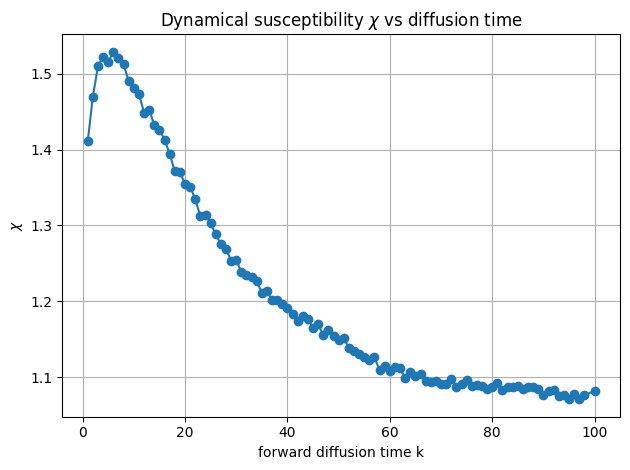

In [ ]:
# plot susceptibility chi vs diffusion time
chi = C.sum(dim=(-1, -2)) / C.diagonal(dim1=-2, dim2=-1).sum(dim=-1)

chi_alt = C_alt.sum(dim=(-1, -2)) / C_alt.diagonal(dim1=-2, dim2=-1).sum(dim=-1)

# n = C.shape[-1]
# mask_offdiag = ~torch.eye(n, dtype=torch.bool, device=C.device)
# chi = C[:, mask_offdiag].sum(dim=-1)


t = k_values  # or k_values / T if you want normalized diffusion time

plt.figure()
plt.plot(t[1:].cpu(), chi[1:].cpu(), marker="o")
# plt.plot(k_values_alt[1:].cpu(), chi_alt[1:].cpu(), marker="x")
plt.xlabel("forward diffusion time k")
plt.ylabel(r"$\chi$")
plt.title(r"efp susceptibility $\chi$ vs diffusion time")
plt.grid(True)
plt.tight_layout()
plt.show()

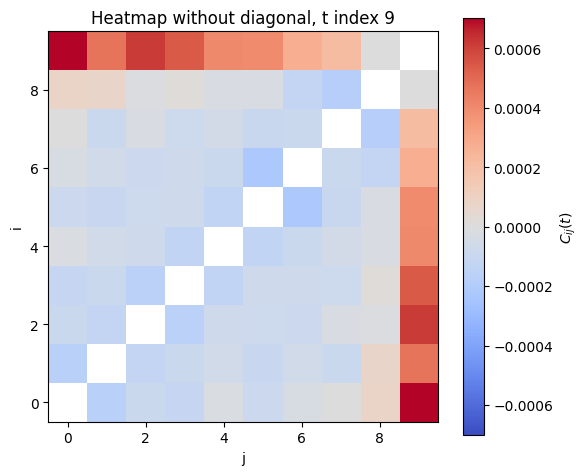

In [45]:
#plot heatmap of C at a specific diffusion time index
t_idx = 9  # choose which diffusion time index to plot

C_t = C[t_idx].detach().cpu()

mask = torch.eye(C_t.shape[0], dtype=torch.bool)
C_t[mask] = float("nan")

plt.figure(figsize=(6, 5))

vmax = torch.nan_to_num(C_t, nan=0.0).abs().max().item()

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="white")   # diagonal will show as white

plt.imshow(C_t, origin="lower", cmap=cmap, vmin=-vmax, vmax=vmax)
plt.colorbar(label=r"$C_{ij}(t)$")
plt.xlabel("j")
plt.ylabel("i")
plt.title(f"Heatmap without diagonal, t index {t_idx}")
plt.tight_layout()
plt.show()

torch.Size([1985566, 10, 3])
tensor([[ 4.1447e-03,  1.0721e-04,  8.0805e-04],
        [-6.4884e-04, -5.9388e-04, -1.1776e-05],
        [-6.4890e-03, -1.3195e-02,  1.3159e-02],
        [-5.8208e-03, -6.5185e-03, -5.6640e-03],
        [ 4.9229e-04,  4.9916e-04, -2.2519e-03],
        [-2.0687e-02, -1.1064e-02,  2.3667e-03],
        [-1.6709e-01, -9.8587e-02,  4.1017e-02],
        [-2.1173e-01, -1.2188e-01,  5.4451e-02],
        [ 1.5143e-02,  9.6056e-03, -5.6234e-03],
        [ 3.9268e-01,  2.4163e-01, -9.8251e-02]])
xhat shape: torch.Size([1, 20, 2000, 10, 3])
x0 shape:  torch.Size([2000, 10, 3])
Originally Available EFPs:
  Prime: 23691
  Composite: 21540
  Total:  45231
Current Stored EFPs:
  Prime: 54
  Composite: 48
  Total:  102
efp_x0 shape: (2000, 102)
efp_xhat shape: (1, 20, 2000, 102)
computing EFPs for t index 1/1
C shape: (1, 102, 102)


FileNotFoundError: [Errno 2] No such file or directory: '/home/harryw/projects/aip-yfkahn/harryw/jet_interpretability/plots/efp_sus.png'

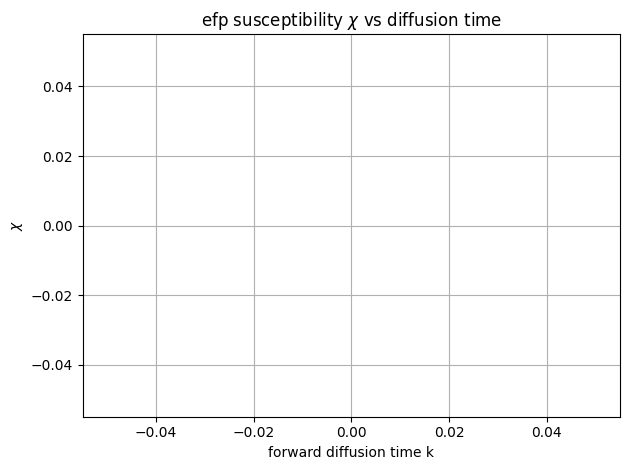

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import energyflow as ef

def calc_correlator(xhat, x0, device):
    p_diff = xhat.to(device) - x0[None, None, :, :].to(device)  # (n_t, n_traj, n_events, 10, 3)
    # p_diff: (n_t, n_traj, n_events, n_particles, 3)
    # redefine sigma_i as the vector momentum error
    sigma_vec = torch.abs(p_diff)  # (t, r, e, i, k), where k = px,py,pz component

    print("sigma_vec shape:", sigma_vec.shape)

    # <sigma_i> over trajectories
    mean_sigma = sigma_vec.mean(dim=1)  # (t, e, i, k)
    print("mean_sigma shape:", mean_sigma.shape)

    # <sigma_i · sigma_j> over trajectories
    mean_dot_ij = torch.einsum(
        "treik,trejk->teij",
        sigma_vec,
        sigma_vec,
    ) / sigma_vec.shape[1]
    print("mean_dot_ij shape:", mean_dot_ij.shape)

    # <sigma_i> · <sigma_j>
    dot_mean_ij = torch.einsum(
        "teik,tejk->teij",
        mean_sigma,
        mean_sigma,
    )
    print("dot_mean_ij shape:", dot_mean_ij.shape)

    # C_{x0,ij}(t) for each event
    C_event = mean_dot_ij - dot_mean_ij  # (t, e, i, j)

    # average over events
    C = C_event.mean(dim=1)  # (t, i, j)

    print("C shape:", C.shape)
    
    return C

def calc_correlator_scalar_sigma(xhat, x0, device):
    p_diff = xhat.to(device) - x0[None, None, :, :].to(device)  # (n_t, n_traj, n_events, 10, 3)
    # p_diff: (n_t, n_traj, n_events, n_particles, 3)
    # redefine sigma_i as the vector momentum error
    sigma_vec = torch.norm(p_diff, dim=-1)  # (t, r, e, i), where i = particle index

    print("sigma_vec shape:", sigma_vec.shape)

    # <sigma_i> over trajectories
    mean_sigma = sigma_vec.mean(dim=1)  # (t, e, i)
    print("mean_sigma shape:", mean_sigma.shape)

    # <sigma_i · sigma_j> over trajectories
    mean_dot_ij = torch.einsum(
        "trei,trej->teij",
        sigma_vec,
        sigma_vec,
    ) / sigma_vec.shape[1]
    print("mean_dot_ij shape:", mean_dot_ij.shape)

    # C_{x0,ij}(t) for each event
    C_event = mean_dot_ij - mean_sigma[:, :, :, None] * mean_sigma[:, :, None, :]  # (t, e, i, j)

    # average over events
    C = C_event.mean(dim=1)  # (t, i, j)

    print("C shape:", C.shape)
    
    return C

def p3_to_p4_np(p3):
    """
    p3: (..., N, 3)
    returns p4: (..., N, 4) in [E, px, py, pz]
    """
    if torch.is_tensor(p3):
        p3 = p3.detach().cpu().float().numpy()

    E = np.linalg.norm(p3, axis=-1, keepdims=True)
    return np.concatenate([E, p3], axis=-1)


def calc_correlator_efp(xhat, x0):
    """
    xhat: (T, n_traj, n_events, n_particles, 3)
    x0:   (n_events, n_particles, 3)

    Returns:
        C: (T, n_efp, n_efp), NumPy array
    """
    x0_np = x0.detach().cpu().float().numpy()
    xhat_np = xhat.detach().cpu().float().numpy()

    T, n_diff, n_events, n_particles, _ = xhat_np.shape

    efpset = ef.EFPSet(
        "d<=5",
        measure="ee",
        beta=2,
        normed=True,
        verbose=True,
    )

    # Original events: p3 -> p4
    x0_p4 = p3_to_p4_np(x0_np)

    # Compute EFPs for x0
    efp_x0 = np.asarray([efpset.compute(event) for event in x0_p4])
    # shape: (n_events, n_efp)

    n_efp = efp_x0.shape[1]

    print("efp_x0 shape:", efp_x0.shape)

    efp_xhat = np.full(
        (T, n_diff, n_events, n_efp),
        np.nan,
        dtype=np.float64,
    )

    print("efp_xhat shape:", efp_xhat.shape)

    for i in range(T):
        print(f"computing EFPs for t index {i+1}/{T}")

        for j in range(n_diff):
            # Convert whole batch of denoised p3 events to p4
            xhat_p4 = p3_to_p4_np(xhat_np[i, j])
            # shape: (n_events, n_particles, 4)

            for k, event in enumerate(xhat_p4):
                if np.isfinite(event).all():
                    efp_xhat[i, j, k] = efpset.compute(event)

    # sigma_a = |EFP_a(xhat) - EFP_a(x0)|
    diff = np.abs(efp_xhat - efp_x0[None, None, :, :])
    # shape: (T, n_diff, n_events, n_efp)

    # <sigma_a> over trajectories
    diff_avg = np.nanmean(diff, axis=1)
    # shape: (T, n_events, n_efp)

    # <sigma_a sigma_b> over trajectories
    correlator = np.einsum("trea,treb->treab", diff, diff)
    correlator_avg = np.nanmean(correlator, axis=1)
    # shape: (T, n_events, n_efp, n_efp)

    # connected correlator for each event
    C_event = correlator_avg - np.einsum("tea,teb->teab", diff_avg, diff_avg)

    # average over events
    C = np.nanmean(C_event, axis=1)
    # shape: (T, n_efp, n_efp)

    print("C shape:", C.shape)

    return torch.from_numpy(C)

    # Compute simga, C_ij, and C
device = "cuda"
x0 = torch.load("/home/hiboy/jet_interpretability_dataset/pythia_events/intermediate_by_nbranch/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=8_Nparticles=10_p3_normalized.pt")
# x0 = torch.load("/home/hiboy/jet_interpretability_dataset/pythia_events/intermediate_by_nbranch/ee2qqbar_S=2000GeV_a=0p1365_N=100000_NBranch=8_Nparticles=10_p3.pt")
print(x0.shape)
print(x0[0, :, :])
# data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/xhats_many_traj_qspace_k~5-100.pt")
# data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/xhats_many_traj_qspace_k~1-10.pt")
data = torch.load("/home/hiboy/jet_interpretability_dataset/forward_backward_outputs/N=1985566_xhats_many_traj_qspace_diffusionpy_k~0-100_timesteps=100.pt")
k_values = data['k_values'][::100]
xhat = data['xhats'][::100]
x0 = x0[:xhat.shape[2], :, :]
print("xhat shape:", xhat.shape)
print("x0 shape: ", x0.shape)

# C = calc_correlator(xhat, x0, device)
C = calc_correlator_efp(xhat, x0)

# plot susceptibility chi vs diffusion time
chi = C.sum(dim=(-1, -2)) / C.diagonal(dim1=-2, dim2=-1).sum(dim=-1)

# chi_alt = C_alt.sum(dim=(-1, -2)) / C_alt.diagonal(dim1=-2, dim2=-1).sum(dim=-1)

# n = C.shape[-1]
# mask_offdiag = ~torch.eye(n, dtype=torch.bool, device=C.device)
# chi = C[:, mask_offdiag].sum(dim=-1)


t = k_values  # or k_values / T if you want normalized diffusion time

plt.figure()
plt.plot(t[1:].cpu(), chi[1:].cpu(), marker="o")
# plt.plot(k_values_alt[1:].cpu(), chi_alt[1:].cpu(), marker="x")
plt.xlabel("forward diffusion time k")
plt.ylabel(r"$\chi$")
plt.title(r"efp susceptibility $\chi$ vs diffusion time")
plt.grid(True)
plt.tight_layout()
plt.savefig("/home/harryw/projects/aip-yfkahn/harryw/jet_interpretability/plots/efp_sus.png")